# Roman Urdu Hate Speech Detection
## Notebook 04:

**Team:** Muhammad Hunain Ashraf (463395) | Arfa Abdul Nasir (456634)

## 0. Setup & GPU Check

In [1]:
!pip install transformers sentencepiece scikit-learn torch --quiet

import os, json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix,
                              classification_report)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results',     exist_ok=True)

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


---
## 1. Load Artefacts & Data

In [ ]:
# Update path to your Kaggle input directory 
DATA_ROOT = '/kaggle/input/datasets/muhammadhunainashraf/new-roman-urdu'

with open(f'{DATA_ROOT}/config.json') as f:
    CONFIG = json.load(f)
print('Config:', json.dumps(CONFIG, indent=2))

VOCAB_SIZE    = CONFIG['vocab_size']
CHAR_VOC_SIZE = CONFIG['char_vocab_size']
PAD_IDX       = CONFIG['pad_idx']
UNK_IDX       = CONFIG['unk_idx']
CHAR_PAD_IDX  = CONFIG['char_pad_idx']
MAX_SEQ_LEN   = CONFIG['max_seq_len']
CHAR_MAX_LEN  = CONFIG['char_max_len']
EMBED_DIM     = CONFIG['embed_dim']         # 100 in config but matrix is 300 — use matrix shape

with open(f'{DATA_ROOT}/word2idx.json',  encoding='utf-8') as f: word2idx = json.load(f)
with open(f'{DATA_ROOT}/idx2word.json',  encoding='utf-8') as f: idx2word = {int(k): v for k,v in json.load(f).items()}
with open(f'{DATA_ROOT}/char2idx.json')  as f: char2idx = json.load(f)
with open(f'{DATA_ROOT}/label2idx.json') as f: label2idx = json.load(f)
with open(f'{DATA_ROOT}/idx2label.json') as f: idx2label = {int(k): v for k,v in json.load(f).items()}

X_train      = np.load(f'{DATA_ROOT}/X_train.npy')
X_train_char = np.load(f'{DATA_ROOT}/X_train_char.npy')
y_train      = np.load(f'{DATA_ROOT}/y_train.npy')

X_val        = np.load(f'{DATA_ROOT}/X_val.npy')
X_val_char   = np.load(f'{DATA_ROOT}/X_val_char.npy')
y_val        = np.load(f'{DATA_ROOT}/y_val.npy')

X_test       = np.load(f'{DATA_ROOT}/X_test.npy')
X_test_char  = np.load(f'{DATA_ROOT}/X_test_char.npy')
y_test       = np.load(f'{DATA_ROOT}/y_test.npy')

embed_matrix = np.load(f'{DATA_ROOT}/embed_matrix.npy')  # (vocab, actual_embed_dim)
EMBED_DIM    = embed_matrix.shape[1]   # use actual dim from matrix, not config

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Embedding matrix: {embed_matrix.shape}  → EMBED_DIM={EMBED_DIM}')

# Class distribution (informational only — no weights applied, augmentation handles balance)
n_hate    = int((y_train == 1).sum())
n_nothate = int((y_train == 0).sum())
print(f'n_hate={n_hate:,} | n_not_hate={n_nothate:,}')

# Load text for any qualitative checks
df_train = pd.read_csv(f'{DATA_ROOT}/train.csv')
df_val   = pd.read_csv(f'{DATA_ROOT}/val.csv')
df_test  = pd.read_csv(f'{DATA_ROOT}/test.csv')

# Load raw texts for XLM-RoBERTa
train_texts = df_train['text'].tolist()
val_texts   = df_val['text'].tolist()
test_texts  = df_test['text'].tolist()

Config: {
  "vocab_size": 34043,
  "char_vocab_size": 42,
  "pad_idx": 0,
  "unk_idx": 1,
  "char_pad_idx": 0,
  "max_seq_len": 64,
  "char_max_len": 200,
  "embed_dim": 300,
  "min_freq": 3,
  "num_classes": 2,
  "num_fine_classes": 5,
  "random_seed": 42,
  "train_size": 89985,
  "val_size": 14833,
  "test_size": 14833,
  "fasttext_dim": 300
}
Train: (89985, 64) | Val: (14833, 64) | Test: (14833, 64)
Embedding matrix: (34043, 300)  → EMBED_DIM=300
n_hate=26,470 | n_not_hate=63,515


---
## 2. Evaluation & Plotting Utilities

In [3]:
ALL_RESULTS = {}

def evaluate_predictions(y_true, y_pred, model_name, verbose=True):
    metrics = {
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'f1_hate':     round(f1_score(y_true, y_pred, pos_label=1, average='binary'), 4),
        'f1_not_hate': round(f1_score(y_true, y_pred, pos_label=0, average='binary'), 4),
        'precision':   round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':      round(recall_score(y_true, y_pred, average='weighted'), 4),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    ALL_RESULTS[model_name] = metrics
    if verbose:
        print(f'\n=== {model_name} ===')
        for k, v in metrics.items():
            if k != 'confusion_matrix': print(f'  {k:<18}: {v}')
        print(classification_report(y_true, y_pred, target_names=['not_hate', 'hate']))
    return metrics

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['not_hate','hate'], yticklabels=['not_hate','hate'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'./results/cm_{model_name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train Loss', color=PALETTE[0])
    axes[0].plot(history['val_loss'],   label='Val Loss',   color=PALETTE[1])
    axes[0].set_title(f'{model_name} — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train F1', color=PALETTE[0])
    axes[1].plot(history['val_f1'],   label='Val F1',   color=PALETTE[1])
    axes[1].set_title(f'{model_name} — Weighted F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'./results/curves_{model_name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

print('Utilities ready.')

Utilities ready.


---
## 3. Loss Functions

### Focal Loss
Focuses learning on hard, misclassified examples regardless of class.
**γ (gamma)**: down-weights easy, confident examples and up-weights hard ones.
No alpha weighting - slight augmentation on all three datasets handles balance.

### R-Drop regularisation
Runs each batch through the model **twice** with different dropout masks.
Adds a symmetric KL divergence between the two output distributions.


total_loss = [FocalLoss(out1, y) + FocalLoss(out2, y)] / 2    ← task loss
           + α × sym_KL(out1, out2)                           ← R-Drop consistency


In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss with focusing and optional label smoothing.

    Args:
        gamma      : focusing parameter — 0 = standard CE, 2 = standard focal
        alpha      : per-class weight tensor (unused; set to None)
        smoothing  : label smoothing epsilon (0 = no smoothing)
                     Smoothing prevents the model from becoming overconfident
                     on training labels, which reduces memorisation.
    """
    def __init__(self, gamma=2.0, alpha=None, smoothing=0.1, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha       # tensor of shape (num_classes,) or None
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits  : (B, C)  raw model outputs
        targets : (B,)    integer class indices
        """
        num_classes = logits.size(1)
        log_probs   = F.log_softmax(logits, dim=1)      # (B, C)
        probs       = log_probs.exp()                   # (B, C)

        # Label smoothing 
        # Hard targets → soft targets: (1-ε) for true class, ε/(C-1) for others
        if self.smoothing > 0:
            with torch.no_grad():
                smooth_targets = torch.full_like(log_probs, self.smoothing / (num_classes - 1))
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
            nll = -(smooth_targets * log_probs).sum(dim=1)  # (B,)
        else:
            nll = F.nll_loss(log_probs, targets, reduction='none')  # (B,)

        # Focal weighting 
        # p_t = probability assigned to the TRUE class
        p_t         = probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (B,)
        focal_weight = (1 - p_t) ** self.gamma                          # (B,)
        loss         = focal_weight * nll                                # (B,)

        #  Class alpha weighting
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]  # (B,)
            loss    = alpha_t * loss

        if self.reduction == 'mean':  return loss.mean()
        if self.reduction == 'sum':   return loss.sum()
        return loss


def sym_kl_divergence(p_logits, q_logits):
    """
    Symmetric KL divergence between two sets of logits.
    Used as the R-Drop consistency regularisation term.
    KL(P||Q) + KL(Q||P) — symmetric so direction doesn't matter.
    """
    p = F.softmax(p_logits, dim=1)
    q = F.softmax(q_logits, dim=1)
    kl_pq = F.kl_div(F.log_softmax(p_logits, dim=1), q, reduction='batchmean')
    kl_qp = F.kl_div(F.log_softmax(q_logits, dim=1), p, reduction='batchmean')
    return (kl_pq + kl_qp) / 2.0


# Focal Loss: no alpha (augmentation handles class balance) 
CRITERION = FocalLoss(
    gamma     = 2.0,
    alpha     = None,
    smoothing = 0.1,
)

RDROP_ALPHA = 0.5   # weight of KL consistency term

print('Focal Loss: gamma=2.0 | alpha=None | smoothing=0.1')
print(f'R-Drop alpha: {RDROP_ALPHA}')

Focal Loss: gamma=2.0 | alpha=None | smoothing=0.1
R-Drop alpha: 0.5


---
## 4. Dataset Classes 

In [5]:
class WordDataset(Dataset):
    """Word tokens only — for TextCNN and BiGRU."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class DualDataset(Dataset):
    """Word tokens + Character sequence — for DualEncoder."""
    def __init__(self, X_word, X_char, y):
        self.X_word = torch.tensor(X_word, dtype=torch.long)
        self.X_char = torch.tensor(X_char, dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        return self.X_word[i], self.X_char[i], self.y[i]


BATCH = 128

word_train_loader = DataLoader(WordDataset(X_train, y_train), batch_size=BATCH,
    shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
word_val_loader   = DataLoader(WordDataset(X_val,   y_val),   batch_size=BATCH*2,
    shuffle=False, num_workers=2, pin_memory=True)
word_test_loader  = DataLoader(WordDataset(X_test,  y_test),  batch_size=BATCH*2,
    shuffle=False, num_workers=2, pin_memory=True)

dual_train_loader = DataLoader(DualDataset(X_train, X_train_char, y_train), batch_size=BATCH,
    shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
dual_val_loader   = DataLoader(DualDataset(X_val,   X_val_char,   y_val),   batch_size=BATCH*2,
    shuffle=False, num_workers=2, pin_memory=True)
dual_test_loader  = DataLoader(DualDataset(X_test,  X_test_char,  y_test),  batch_size=BATCH*2,
    shuffle=False, num_workers=2, pin_memory=True)

print('Datasets & DataLoaders ready (no fine-grained labels).')

Datasets & DataLoaders ready (no fine-grained labels).


---
## 5. fastText Embedding Initialiser

In [6]:
def load_pretrained_embedding(layer: nn.Embedding, matrix: np.ndarray, freeze=False):
    assert matrix.shape == tuple(layer.weight.shape), \
        f'Shape mismatch: layer={layer.weight.shape}, matrix={matrix.shape}'
    with torch.no_grad():
        layer.weight.copy_(torch.tensor(matrix, dtype=torch.float32))
        layer.weight[0] = 0.0   # PAD always zero
    layer.weight.requires_grad = not freeze
    print(f'  [fastText] {matrix.shape} — {"frozen" if freeze else "fine-tunable"}')

print('Embedding helper ready.')

Embedding helper ready.


---
## 6. Training Engine

- **Two forward passes per batch** for R-Drop 
- **Focal Loss** instead of CE
- **Differential parameter groups** so embedding and non-embedding get different LRs
- **max_epochs=15, patience=5**


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, mode='max', min_delta=1e-4):
        self.patience  = patience
        self.mode      = mode
        self.min_delta = min_delta
        self.best      = -np.inf if mode == 'max' else np.inf
        self.counter   = 0
        self.stop      = False

    def __call__(self, value):
        improved = (value > self.best + self.min_delta) if self.mode == 'max' \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def get_param_groups(model, embed_lr=1e-5, other_lr=5e-4):
    """
    Split parameters into two groups:
      - Embedding parameters: low LR (1e-5) to preserve fastText pre-training
      - All other parameters: normal LR (5e-4)

    This is the primary fix for embedding overfitting.
    The embedding has 80-94% of total params - same LR as conv/GRU layers
    overwrites the pre-trained fastText representations within 2 epochs.
    """
    embed_params = []
    other_params = []
    for name, param in model.named_parameters():
        if 'embedding' in name.lower():
            embed_params.append(param)
        else:
            other_params.append(param)
    return [
        {'params': embed_params, 'lr': embed_lr,  'name': 'embedding'},
        {'params': other_params, 'lr': other_lr,  'name': 'other'},
    ]


def train_one_epoch_rdrop(model, loader, optimizer, scaler, rdrop_alpha, is_dual=False):
    """
    Training step with R-Drop:
      1. Forward the same batch TWICE-different dropout masks each time
      2. Compute Focal Loss averaged over both passes (task loss)
      3. Add symmetric KL divergence (R-Drop consistency loss)
      4. total = avg_focal + rdrop_alpha * sym_KL
    """
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        optimizer.zero_grad(set_to_none=True)

        if is_dual:
            x_word, x_char, labels = [b.to(DEVICE) for b in batch]
        else:
            x_word, labels = [b.to(DEVICE) for b in batch]
            x_char = None

        with autocast(enabled=(DEVICE.type == 'cuda')):
            # First forward pass
            logits1 = model(x_word, x_char) if is_dual else model(x_word)
            # Second forward pass (different dropout mask)
            logits2 = model(x_word, x_char) if is_dual else model(x_word)

            # Task loss: Focal, averaged over both passes
            task_loss = (CRITERION(logits1, labels) + CRITERION(logits2, labels)) / 2.0

            # R-Drop consistency loss: symmetric KL between the two pass outputs
            consistency_loss = sym_kl_divergence(logits1, logits2)

            loss = task_loss + rdrop_alpha * consistency_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Use pass-1 predictions for metrics
        total_loss  += loss.item() * labels.size(0)
        all_preds.extend(logits1.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1


@torch.no_grad()
def evaluate_loader(model, loader, is_dual=False):
    """Single forward pass for evaluation (no R-Drop, no training noise)."""
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch in loader:
        if is_dual:
            x_word, x_char, labels = [b.to(DEVICE) for b in batch]
        else:
            x_word, labels = [b.to(DEVICE) for b in batch]
            x_char = None

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(x_word, x_char) if is_dual else model(x_word)
            loss   = CRITERION(logits, labels)

        probs = F.softmax(logits, dim=1)
        total_loss  += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_and_evaluate(
    model, train_loader, val_loader, test_loader,
    model_name,
    max_epochs = 15,
    embed_lr   = 1e-5,
    other_lr   = 5e-4,
    weight_decay  = 1e-4,
    patience      = 5,
    rdrop_alpha   = 0.5,
    is_dual       = False,
    swa_epochs    = 0,
):
    """
    Full training + evaluation pipeline.
    SWA has been removed from this notebook version.
    """
    model = model.to(DEVICE)

    # Differential parameter groups
    param_groups = get_param_groups(model, embed_lr=embed_lr, other_lr=other_lr)
    optimizer    = AdamW(param_groups, weight_decay=weight_decay)

    # Cosine annealing decays LR smoothly from peak to near-zero
    scheduler  = CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=embed_lr * 0.1)
    scaler     = GradScaler(enabled=(DEVICE.type == 'cuda'))
    early_stop = EarlyStopping(patience=patience, mode='max')

    history    = defaultdict(list)
    best_f1    = -np.inf
    best_ckpt  = f'./checkpoints/{model_name.replace(" ","_")}.pt'

    total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    embed_p = sum(p.numel() for g in param_groups if g['name']=='embedding' for p in g['params'])
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Total params: {total_p:,} | Embedding: {embed_p:,} ({embed_p/total_p*100:.1f}%)')
    print(f'LR -> embed={embed_lr} | other={other_lr}')
    print(f'R-Drop alpha={rdrop_alpha} | max_epochs={max_epochs} | patience={patience}')
    print(f'{"="*60}')

    t_start = time.time()

    for epoch in range(1, max_epochs + 1):
        t_ep = time.time()

        tr_loss, tr_f1 = train_one_epoch_rdrop(
            model, train_loader, optimizer, scaler, rdrop_alpha, is_dual
        )
        va_loss, va_f1, _, _, _ = evaluate_loader(model, val_loader, is_dual)

        history['train_loss'].append(tr_loss)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_f1)

        scheduler.step()

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_ckpt)

        early_stop(va_f1)
        current_lrs = [g['lr'] for g in optimizer.param_groups]
        print(f'Ep {epoch:02d}/{max_epochs} | '
              f'tr={tr_loss:.4f}/{tr_f1:.4f} | '
              f'va={va_loss:.4f}/{va_f1:.4f} | '
              f'LR=[{current_lrs[0]:.1e},{current_lrs[1]:.1e}] | '
              f'{time.time()-t_ep:.1f}s'
              + (' <- best' if va_f1 == best_f1 else ''))

        if early_stop.stop:
            print(f'Early stopping at epoch {epoch}.')
            break

    print(f'\nTraining done. Best val F1: {best_f1:.4f} | Time: {(time.time()-t_start)/60:.1f} min')

    # Load best checkpoint for test evaluation
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    eval_model = model

    # Test evaluation
    _, _, preds, labels, probs = evaluate_loader(eval_model, test_loader, is_dual)
    evaluate_predictions(labels, preds, model_name)
    plot_confusion_matrix(labels, preds, model_name)
    plot_training_curves(dict(history), model_name)

    np.save(f'./results/{model_name.replace(" ","_")}_probs.npy', probs)
    total_time = time.time() - t_start
    print(f'Total time: {total_time/60:.1f} min')
    return eval_model, dict(history), probs

print('Training engine ready.')

Training engine ready.


---
## 7. Model M1 - TextCNN

  [fastText] (34043, 300) — fine-tunable

Training: TextCNN
Total params: 11,422,630 | Embedding: 10,212,900 (89.4%)
LR -> embed=1e-05 | other=0.0005
R-Drop alpha=0.5 | max_epochs=15 | patience=5
Ep 01/15 | tr=0.2144/0.8361 | va=0.0777/0.8731 | LR=[9.9e-06,4.9e-04] | 18.4s <- best
Ep 02/15 | tr=0.0769/0.8860 | va=0.0716/0.8818 | LR=[9.6e-06,4.8e-04] | 17.7s <- best
Ep 03/15 | tr=0.0658/0.9093 | va=0.0676/0.8919 | LR=[9.1e-06,4.5e-04] | 17.9s <- best
Ep 04/15 | tr=0.0557/0.9300 | va=0.0669/0.8940 | LR=[8.5e-06,4.2e-04] | 17.7s <- best
Ep 05/15 | tr=0.0472/0.9469 | va=0.0716/0.8960 | LR=[7.8e-06,3.8e-04] | 17.6s <- best
Ep 06/15 | tr=0.0407/0.9579 | va=0.0762/0.8967 | LR=[6.9e-06,3.3e-04] | 17.5s <- best
Ep 07/15 | tr=0.0355/0.9676 | va=0.0795/0.8980 | LR=[6.0e-06,2.8e-04] | 17.5s <- best
Ep 08/15 | tr=0.0311/0.9738 | va=0.0922/0.8993 | LR=[5.0e-06,2.2e-04] | 17.6s <- best
Ep 09/15 | tr=0.0276/0.9794 | va=0.1001/0.8983 | LR=[4.1e-06,1.7e-04] | 17.5s
Ep 10/15 | tr=0.0251/0.9824 | va=0.103

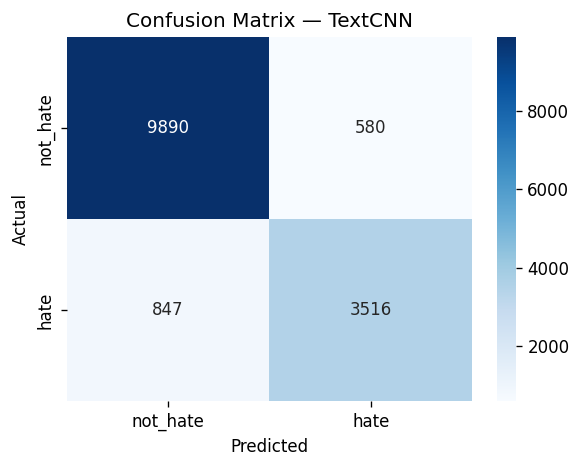

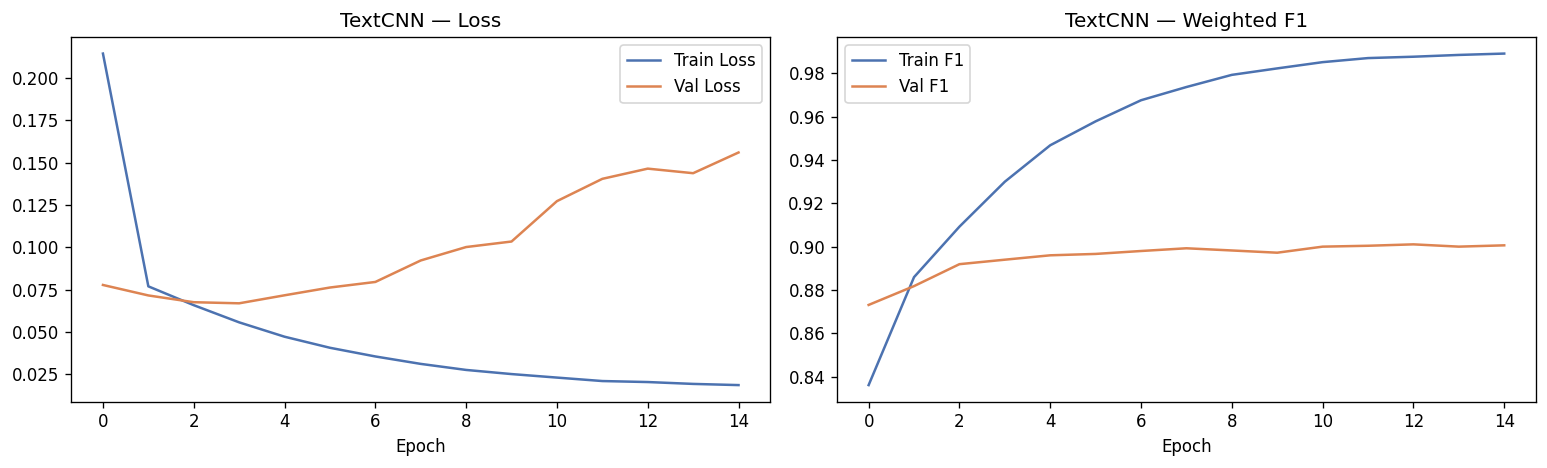

Total time: 4.4 min


In [8]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4,5),
                 num_classes=2, pad_idx=PAD_IDX, dropout=0.5):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs      = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout    = nn.Dropout(dropout)
        self.batch_norm = nn.BatchNorm1d(num_filters * len(filter_sizes))
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 128)
        self.fc2 = nn.Linear(128, num_classes)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x, x_char=None):   # x_char ignored
        emb = self.embedding(x).permute(0, 2, 1)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        out = self.batch_norm(out)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        return self.fc2(out)


set_seed()
cnn_model = TextCNN()
load_pretrained_embedding(cnn_model.embedding, embed_matrix)

cnn_model, cnn_history, cnn_probs = train_and_evaluate(
    cnn_model, word_train_loader, word_val_loader, word_test_loader,
    model_name   = 'TextCNN',
    max_epochs   = 15,
    embed_lr     = 1e-5,
    other_lr     = 5e-4,
    patience     = 5,
    rdrop_alpha  = 0.5,
    is_dual      = False,
    swa_epochs   = 3,
)

---
## 8. Model M2 - BiGRU + Additive Attention

  [fastText] (34043, 300) — fine-tunable

Training: BiGRU_Attention
Total params: 10,889,702 | Embedding: 10,212,900 (93.8%)
LR -> embed=1e-05 | other=0.0005
R-Drop alpha=0.5 | max_epochs=25 | patience=5
Ep 01/25 | tr=0.1008/0.8459 | va=0.0728/0.8798 | LR=[1.0e-05,5.0e-04] | 15.7s <- best
Ep 02/25 | tr=0.0850/0.8739 | va=0.0735/0.8859 | LR=[9.9e-06,4.9e-04] | 15.6s <- best
Ep 03/25 | tr=0.0794/0.8840 | va=0.0669/0.8894 | LR=[9.7e-06,4.8e-04] | 15.3s <- best
Ep 04/25 | tr=0.0752/0.8915 | va=0.0643/0.8962 | LR=[9.4e-06,4.7e-04] | 15.4s <- best
Ep 05/25 | tr=0.0719/0.8977 | va=0.0634/0.8984 | LR=[9.1e-06,4.5e-04] | 15.5s <- best
Ep 06/25 | tr=0.0694/0.9035 | va=0.0620/0.9018 | LR=[8.8e-06,4.3e-04] | 15.6s <- best
Ep 07/25 | tr=0.0672/0.9075 | va=0.0622/0.9041 | LR=[8.4e-06,4.1e-04] | 15.7s <- best
Ep 08/25 | tr=0.0650/0.9123 | va=0.0619/0.9035 | LR=[7.9e-06,3.8e-04] | 15.4s
Ep 09/25 | tr=0.0629/0.9155 | va=0.0596/0.9047 | LR=[7.4e-06,3.6e-04] | 15.5s <- best
Ep 10/25 | tr=0.0611/0.9198 | 

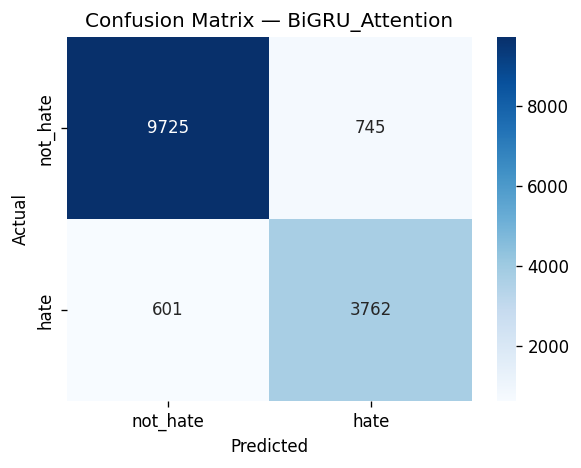

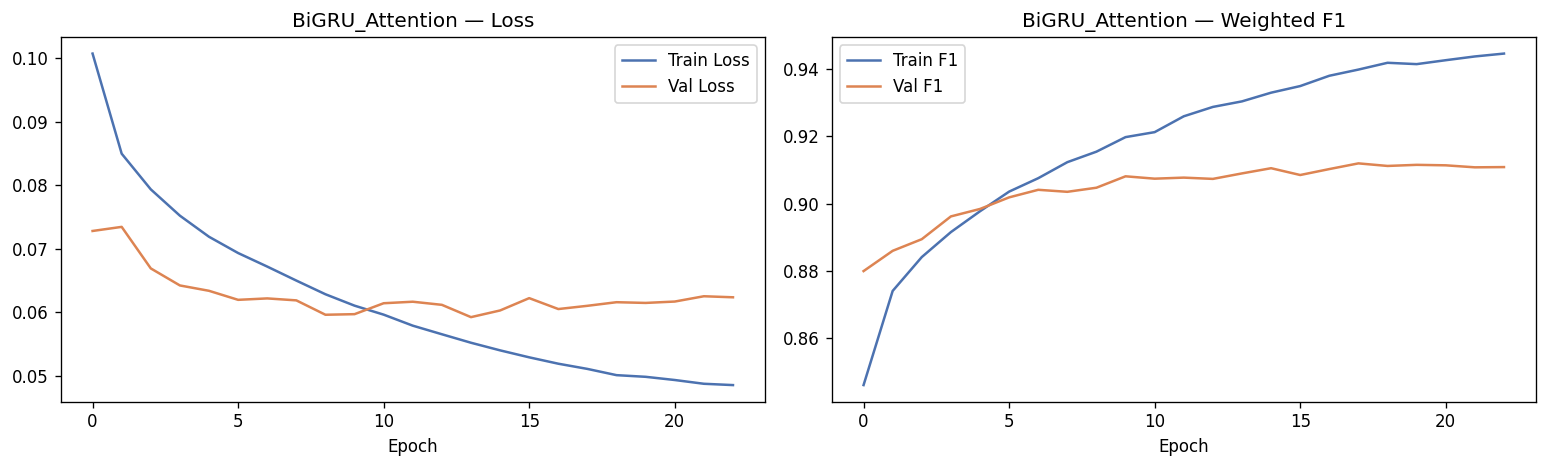

Total time: 6.0 min


In [9]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H):
        scores  = self.v(torch.tanh(self.attn(H))).squeeze(-1)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        return (H * weights).sum(dim=1)


class BiGRUAttention(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 hidden_dim=128, num_classes=2, pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.bigru     = nn.GRU(embed_dim, hidden_dim, batch_first=True,
                                bidirectional=True, num_layers=2,
                                dropout=dropout)
        self.attention  = AdditiveAttention(hidden_dim)
        self.dropout    = nn.Dropout(dropout)
        self.batch_norm = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x, x_char=None):
        emb     = self.dropout(self.embedding(x))
        H, _    = self.bigru(emb)
        ctx     = self.attention(H)
        ctx     = self.batch_norm(ctx)
        ctx     = self.dropout(ctx)
        out     = F.relu(self.fc1(ctx))
        out     = self.dropout(out)
        return self.fc2(out)


set_seed()
gru_model = BiGRUAttention()
load_pretrained_embedding(gru_model.embedding, embed_matrix)

gru_model, gru_history, gru_probs = train_and_evaluate(
    gru_model, word_train_loader, word_val_loader, word_test_loader,
    model_name   = 'BiGRU_Attention',
    max_epochs   = 25,
    embed_lr     = 1e-5,
    other_lr     = 5e-4,
    patience     = 5,
    rdrop_alpha  = 0.5,
    is_dual      = False,
    swa_epochs   = 3,
)

---
## 9. Model M3 - DualEncoder (Word-CNN + Char-CNN + Gated Fusion)

The gated fusion: gate learns per-sample how much to trust word vs char branch.

  [fastText] (34043, 300) — fine-tunable

Training: DualEncoder
Total params: 12,818,982 | Embedding: 10,215,588 (79.7%)
LR -> embed=1e-05 | other=0.0005
R-Drop alpha=0.5 | max_epochs=15 | patience=5
Ep 01/15 | tr=0.1653/0.8225 | va=0.0870/0.8571 | LR=[9.9e-06,4.9e-04] | 28.8s <- best
Ep 02/15 | tr=0.0855/0.8748 | va=0.0783/0.8868 | LR=[9.6e-06,4.8e-04] | 28.8s <- best
Ep 03/15 | tr=0.0762/0.8945 | va=0.0683/0.8944 | LR=[9.1e-06,4.5e-04] | 28.8s <- best
Ep 04/15 | tr=0.0681/0.9131 | va=0.0710/0.8955 | LR=[8.5e-06,4.2e-04] | 28.8s <- best
Ep 05/15 | tr=0.0614/0.9266 | va=0.0664/0.8987 | LR=[7.8e-06,3.8e-04] | 28.8s <- best
Ep 06/15 | tr=0.0551/0.9396 | va=0.0662/0.9009 | LR=[6.9e-06,3.3e-04] | 28.9s <- best
Ep 07/15 | tr=0.0510/0.9478 | va=0.0690/0.8982 | LR=[6.0e-06,2.8e-04] | 28.7s
Ep 08/15 | tr=0.0467/0.9562 | va=0.0662/0.9034 | LR=[5.0e-06,2.2e-04] | 28.8s <- best
Ep 09/15 | tr=0.0435/0.9610 | va=0.0658/0.9032 | LR=[4.1e-06,1.7e-04] | 28.7s
Ep 10/15 | tr=0.0407/0.9661 | va=0.0687/0.

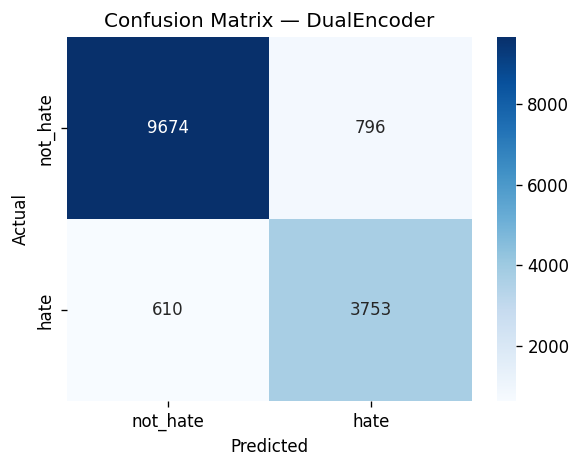

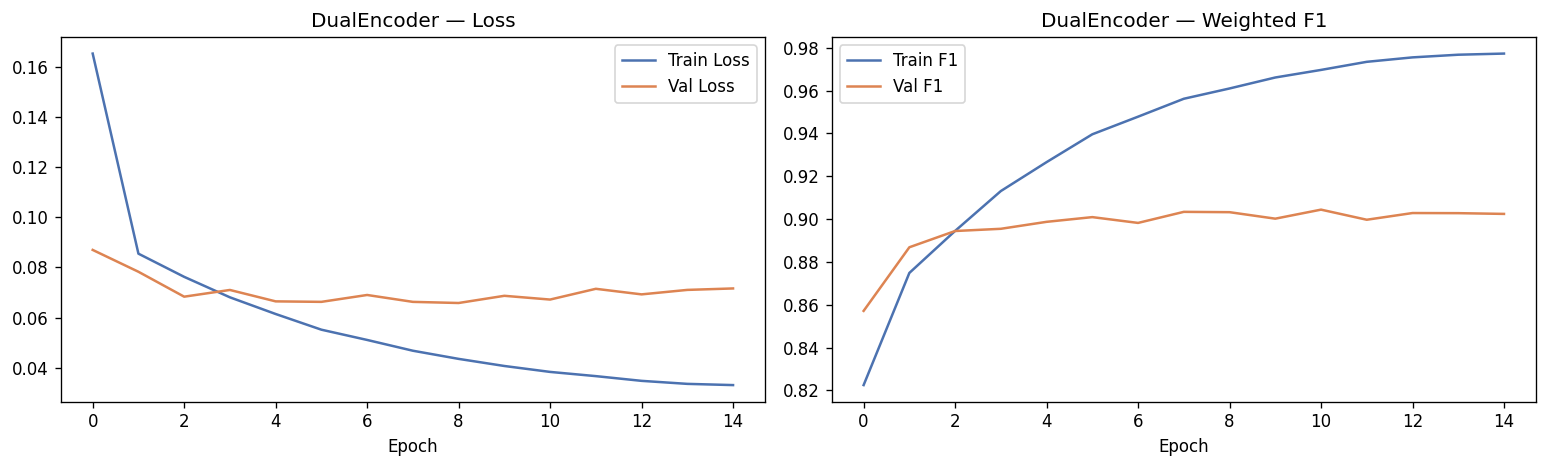

Total time: 7.2 min


In [10]:
class CharCNNEncoder(nn.Module):
    def __init__(self, char_vocab_size=CHAR_VOC_SIZE, char_embed_dim=64,
                 num_filters=128, filter_sizes=(3,4,5,6),
                 char_pad_idx=CHAR_PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(char_vocab_size, char_embed_dim, padding_idx=char_pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(char_embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_dim = num_filters * len(filter_sizes)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')

    def forward(self, x_char):
        emb = self.dropout(self.embedding(x_char)).permute(0, 2, 1)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        return torch.cat(pooled, dim=1)


class WordCNNEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4,5),
                 pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_dim = num_filters * len(filter_sizes)
        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')

    def forward(self, x_word):
        emb = self.dropout(self.embedding(x_word)).permute(0, 2, 1)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        return torch.cat(pooled, dim=1)


class DualEncoderCNN(nn.Module):
    """
    Word-CNN + Char-CNN with learned gated fusion. No multi-task head.

    The gate per-sample decides how much to weight word vs char representation:
      - Standard spelling → gate weights word branch (rich fastText semantics)
      - Heavy spelling variation / OOV → gate weights char branch (char n-gram signal)
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.word_enc = WordCNNEncoder(dropout=dropout)
        self.char_enc = CharCNNEncoder(dropout=dropout)

        word_dim = self.word_enc.out_dim   # 256*4 = 1024
        char_dim = self.char_enc.out_dim   # 128*4 = 512

        self.word_proj = nn.Linear(word_dim, 512)
        self.char_proj = nn.Linear(char_dim, 512)
        self.gate      = nn.Linear(512 * 2, 512)

        self.batch_norm = nn.BatchNorm1d(512)
        self.dropout    = nn.Dropout(dropout)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, num_classes)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x_word, x_char):
        word_rep = F.relu(self.word_proj(self.word_enc(x_word)))
        char_rep = F.relu(self.char_proj(self.char_enc(x_char)))

        gate   = torch.sigmoid(self.gate(torch.cat([word_rep, char_rep], dim=1)))
        fused  = gate * word_rep + (1 - gate) * char_rep

        out    = self.batch_norm(fused)
        out    = self.dropout(out)
        out    = F.relu(self.fc1(out))
        out    = self.dropout(out)
        return self.fc2(out)


set_seed()
dual_model = DualEncoderCNN()
load_pretrained_embedding(dual_model.word_enc.embedding, embed_matrix)

dual_model, dual_history, dual_probs = train_and_evaluate(
    dual_model, dual_train_loader, dual_val_loader, dual_test_loader,
    model_name   = 'DualEncoder',
    max_epochs   = 15,
    embed_lr     = 1e-5,
    other_lr     = 5e-4,
    patience     = 5,
    rdrop_alpha  = 0.5,
    is_dual      = True,
    swa_epochs   = 3,
)

---
## 10. Model M4 - CNN-BiGRU Hierarchical Attention

  [fastText] (34043, 300) — fine-tunable

Training: CNNBiGRU
Total params: 11,861,926 | Embedding: 10,212,900 (86.1%)
LR -> embed=1e-05 | other=0.0005
R-Drop alpha=0.5 | max_epochs=15 | patience=5
Ep 01/15 | tr=0.1174/0.8249 | va=0.0793/0.8690 | LR=[9.9e-06,4.9e-04] | 23.5s <- best
Ep 02/15 | tr=0.0881/0.8666 | va=0.0735/0.8837 | LR=[9.6e-06,4.8e-04] | 23.4s <- best
Ep 03/15 | tr=0.0825/0.8768 | va=0.0685/0.8890 | LR=[9.1e-06,4.5e-04] | 23.4s <- best
Ep 04/15 | tr=0.0777/0.8876 | va=0.0646/0.8976 | LR=[8.5e-06,4.2e-04] | 23.6s <- best
Ep 05/15 | tr=0.0741/0.8956 | va=0.0640/0.8991 | LR=[7.8e-06,3.8e-04] | 23.5s <- best
Ep 06/15 | tr=0.0710/0.9016 | va=0.0641/0.9009 | LR=[6.9e-06,3.3e-04] | 23.5s <- best
Ep 07/15 | tr=0.0684/0.9066 | va=0.0619/0.9013 | LR=[6.0e-06,2.8e-04] | 23.4s <- best
Ep 08/15 | tr=0.0659/0.9125 | va=0.0616/0.9045 | LR=[5.0e-06,2.2e-04] | 23.5s <- best
Ep 09/15 | tr=0.0640/0.9165 | va=0.0609/0.9034 | LR=[4.1e-06,1.7e-04] | 23.2s
Ep 10/15 | tr=0.0619/0.9204 | va=0.05

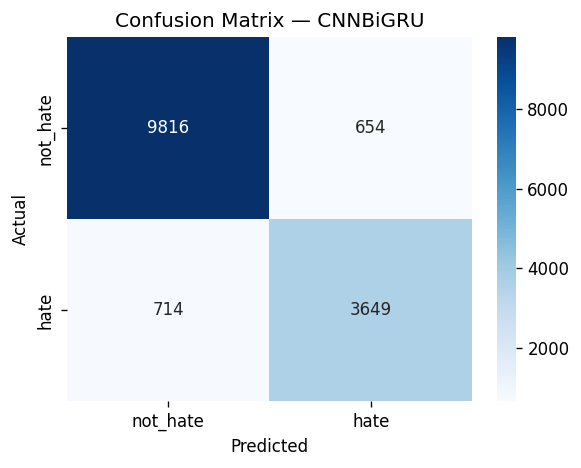

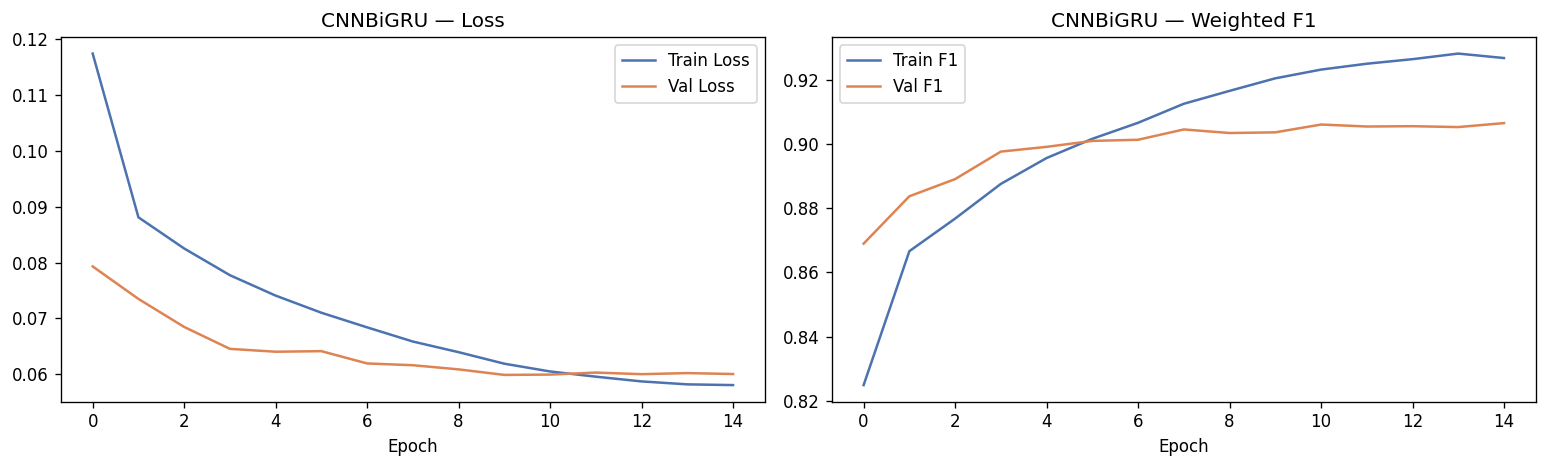

Total time: 5.9 min


In [11]:
class CNNBiGRU(nn.Module):
    """
    Shared embedding → CNN branch + BiGRU branch.
    Cross-branch attention: CNN feature vector queries over GRU hidden states.
    No multi-task head.
    """
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2,3,4),
                 gru_hidden=128, num_classes=2,
                 pad_idx=PAD_IDX, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=fs) for fs in filter_sizes
        ])
        cnn_dim = num_filters * len(filter_sizes)   # 768

        self.bigru = nn.GRU(embed_dim, gru_hidden, batch_first=True,
                             bidirectional=True, num_layers=2, dropout=dropout)
        gru_dim = gru_hidden * 2   # 256

        self.attn_W = nn.Linear(cnn_dim, gru_dim)

        combined_dim = cnn_dim + gru_dim   # 1024
        self.bn    = nn.BatchNorm1d(combined_dim)
        self.fc1   = nn.Linear(combined_dim, 128)
        self.fc2   = nn.Linear(128, num_classes)

        for conv in self.convs:
            nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)

    def forward(self, x_word, x_char=None):   # x_char ignored
        emb = self.dropout(self.embedding(x_word))

        e_perm = emb.permute(0, 2, 1)
        cnn_pooled = [F.adaptive_max_pool1d(F.relu(conv(e_perm)), 1).squeeze(2)
                      for conv in self.convs]
        cnn_out = torch.cat(cnn_pooled, dim=1)

        H, _ = self.bigru(emb)

        Q       = self.attn_W(cnn_out).unsqueeze(1)
        scores  = torch.bmm(Q, H.transpose(1, 2)).squeeze(1)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        attn_ctx = (H * weights).sum(dim=1)

        combined = torch.cat([cnn_out, attn_ctx], dim=1)
        out = self.bn(combined)
        out = self.dropout(out)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        return self.fc2(out)


set_seed()
cgru_model = CNNBiGRU()
load_pretrained_embedding(cgru_model.embedding, embed_matrix)

# CNNBiGRU uses word loader but train_and_evaluate uses is_dual=False
cgru_model, cgru_history, cgru_probs = train_and_evaluate(
    cgru_model, word_train_loader, word_val_loader, word_test_loader,
    model_name   = 'CNNBiGRU',
    max_epochs   = 15,
    embed_lr     = 1e-5,
    other_lr     = 5e-4,
    patience     = 5,
    rdrop_alpha  = 0.5,
    is_dual      = False,
    swa_epochs   = 3,
)

---
## 11. Model M5 - XLM-RoBERTa Fine-tune

In [ ]:
from torch.utils.data import Dataset as TorchDataset

XLM_MODEL_NAME = 'xlm-roberta-base'
xlm_tokenizer  = AutoTokenizer.from_pretrained(XLM_MODEL_NAME)


class XLMDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length',
                                   max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encodings.items()}, self.labels[i]


xlm_train_ds = XLMDataset(train_texts, y_train.tolist(), xlm_tokenizer)
xlm_val_ds   = XLMDataset(val_texts,   y_val.tolist(),   xlm_tokenizer)
xlm_test_ds  = XLMDataset(test_texts,  y_test.tolist(),  xlm_tokenizer)

xlm_train_loader = DataLoader(xlm_train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
xlm_val_loader   = DataLoader(xlm_val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
xlm_test_loader  = DataLoader(xlm_test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

xlm_model = AutoModelForSequenceClassification.from_pretrained(XLM_MODEL_NAME, num_labels=2)
xlm_model = xlm_model.to(DEVICE)

xlm_optimizer = AdamW(xlm_model.parameters(), lr=2e-5, weight_decay=1e-2)
xlm_criterion = nn.CrossEntropyLoss()
xlm_scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))
xlm_scheduler = ReduceLROnPlateau(xlm_optimizer, mode='max', factor=0.5, patience=1)
xlm_early     = EarlyStopping(patience=2, mode='max')

best_xlm_f1   = -np.inf
xlm_history   = defaultdict(list)
XLM_CKPT      = './checkpoints/xlm_roberta.pt'

print(f'XLM-RoBERTa params: {sum(p.numel() for p in xlm_model.parameters() if p.requires_grad):,}')

# Training epochs
for epoch in range(1, 7):
    t_ep = time.time()
    xlm_model.train()
    tr_preds, tr_labels_list, tr_loss_sum = [], [], 0.0

    for enc, labels in xlm_train_loader:
        xlm_optimizer.zero_grad()
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out  = xlm_model(**enc)
            loss = xlm_criterion(out.logits, labels)
        xlm_scaler.scale(loss).backward()
        xlm_scaler.unscale_(xlm_optimizer)
        nn.utils.clip_grad_norm_(xlm_model.parameters(), 1.0)
        xlm_scaler.step(xlm_optimizer)
        xlm_scaler.update()
        tr_loss_sum += loss.item() * labels.size(0)
        tr_preds.extend(out.logits.argmax(1).cpu().numpy())
        tr_labels_list.extend(labels.cpu().numpy())

    tr_f1   = f1_score(tr_labels_list, tr_preds, average='weighted')
    tr_loss = tr_loss_sum / len(xlm_train_ds)

    xlm_model.eval()
    va_preds, va_labels_list, va_loss_sum = [], [], 0.0
    with torch.no_grad():
        for enc, labels in xlm_val_loader:
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            labels = labels.to(DEVICE)
            with autocast(enabled=(DEVICE.type == 'cuda')):
                out  = xlm_model(**enc)
                loss = xlm_criterion(out.logits, labels)
            va_loss_sum += loss.item() * labels.size(0)
            va_preds.extend(out.logits.argmax(1).cpu().numpy())
            va_labels_list.extend(labels.cpu().numpy())

    va_f1   = f1_score(va_labels_list, va_preds, average='weighted')
    va_loss = va_loss_sum / len(xlm_val_ds)

    xlm_history['train_loss'].append(tr_loss)
    xlm_history['train_f1'].append(tr_f1)
    xlm_history['val_loss'].append(va_loss)
    xlm_history['val_f1'].append(va_f1)
    xlm_scheduler.step(va_f1)

    if va_f1 > best_xlm_f1:
        best_xlm_f1 = va_f1
        torch.save(xlm_model.state_dict(), XLM_CKPT)

    xlm_early(va_f1)
    print(f'Ep {epoch} | tr_f1={tr_f1:.4f} va_f1={va_f1:.4f} | {time.time()-t_ep:.0f}s'
          + (' ← best' if va_f1 == best_xlm_f1 else ''))
    if xlm_early.stop:
        print('Early stop.')
        break

xlm_model.load_state_dict(torch.load(XLM_CKPT))
xlm_model.eval()
all_xlm_preds, all_xlm_probs = [], []
with torch.no_grad():
    for enc, _ in xlm_test_loader:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out = xlm_model(**enc)
        all_xlm_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_xlm_probs.extend(F.softmax(out.logits, dim=1).cpu().numpy())

y_pred_xlm  = np.array(all_xlm_preds)
probs_xlm   = np.array(all_xlm_probs)
evaluate_predictions(y_test, y_pred_xlm, 'XLM-RoBERTa')
plot_confusion_matrix(y_test, y_pred_xlm, 'XLM-RoBERTa')
plot_training_curves(dict(xlm_history), 'XLM-RoBERTa')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa params: 278,045,186
Ep 1 | tr_f1=0.8518 va_f1=0.9004 | 785s ← best
Ep 2 | tr_f1=0.9174 va_f1=0.9037 | 786s ← best
Ep 3 | tr_f1=0.9408 va_f1=0.9087 | 786s ← best
Ep 4 | tr_f1=0.9547 va_f1=0.9175 | 785s ← best


---
## 12. Ensemble - Soft Voting

In [ ]:
# 2-model ensemble: DualEncoder + CNNBiGRU 
# DualEncoder: char branch handles spelling variation
# CNNBiGRU: sequential context around detected phrases
# These two have the least correlated failures - best ensemble combination

ens2_probs = (dual_probs + cgru_probs) / 2.0
y_pred_ens2 = ens2_probs.argmax(axis=1)
evaluate_predictions(y_test, y_pred_ens2, 'Ensemble_Dual+CNNBiGRU')
plot_confusion_matrix(y_test, y_pred_ens2, 'Ensemble_Dual+CNNBiGRU')

#  4-model ensemble
ens4_probs  = (cnn_probs + gru_probs + dual_probs + cgru_probs) / 4.0
y_pred_ens4 = ens4_probs.argmax(axis=1)
evaluate_predictions(y_test, y_pred_ens4, 'Ensemble_All4')
plot_confusion_matrix(y_test, y_pred_ens4, 'Ensemble_All4')

#  5-model ensemble: Add XLM-RoBERTa 
ens5_probs  = (cnn_probs + gru_probs + dual_probs + cgru_probs + probs_xlm) / 5.0
y_pred_ens5 = ens5_probs.argmax(axis=1)
evaluate_predictions(y_test, y_pred_ens5, 'Ensemble_All5_with_XLM')
plot_confusion_matrix(y_test, y_pred_ens5, 'Ensemble_All5_with_XLM')

---
## 13. Final Results Summary

In [ ]:
EMNLP_REF = {'accuracy': None, 'f1_weighted': 0.75, 'f1_hate': None,
              'f1_not_hate': None, 'precision': None, 'recall': None}
PREV_BEST  = {'accuracy': 0.9167, 'f1_weighted': 0.9166, 'f1_hate': 0.8577,
              'f1_not_hate': 0.9412, 'precision': 0.9165, 'recall': 0.9167}
ALL_RESULTS['EMNLP2020 (reference)'] = EMNLP_REF
ALL_RESULTS['Prev Best (v2 Ensemble)'] = PREV_BEST

rows = []
for name, m in ALL_RESULTS.items():
    rows.append({
        'Model':          name,
        'Accuracy':       m['accuracy'],
        'F1 (weighted)':  m['f1_weighted'],
        'F1 (hate)':      m['f1_hate'],
        'F1 (not_hate)':  m['f1_not_hate'],
        'Precision':      m['precision'],
        'Recall':         m['recall'],
    })

df_results = pd.DataFrame(rows).set_index('Model')
print('\n=== FINAL TEST RESULTS ===')
print(df_results.to_string())
df_results.to_csv('./results/final_results_v4.csv')

fig, ax = plt.subplots(figsize=(14, 6))
df_plot = df_results[['F1 (weighted)']].dropna().astype(float).sort_values('F1 (weighted)')
colors = ['#C44E52' if 'Prev' in n or 'EMNLP' in n
          else ('#55A868' if 'Ensemble' in n else '#4C72B0') for n in df_plot.index]
ax.barh(df_plot.index, df_plot['F1 (weighted)'], color=colors)
ax.axvline(0.75,   color='gray',   linestyle='--', alpha=0.7, label='EMNLP 2020 (0.75)')
ax.axvline(0.9166, color='orange', linestyle='--', alpha=0.7, label='Prev best v2 (0.9166)')
ax.set_xlabel('Weighted F1')
ax.set_title('Test F1 — v4 (Focal + Diff-LR + R-Drop + XLM-RoBERTa)')
ax.legend(); plt.tight_layout()
plt.savefig('./results/final_comparison_v4.png', bbox_inches='tight')
plt.show()